# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [1]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Respuesta

Explica brevemente para qué utilizaremos cada biblioteca:

- **NumPy:** Para arrays, operaciones con números
- **pandas:** Para DataFrames (Tablas)
- **Matplotlib:** Para hacer gráficos de visualización

## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [2]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv("clientes.csv")
# TODO: muestra las primeras filas
df.head()#si pongo numero se pone ese num de filas

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Representa un cliente.

**¿Qué representa cada columna?**

Representa variables de cada cliente.

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [3]:
# TODO: muestra las dimensiones del DataFrame
df.shape

(180, 10)

### Respuesta

- **Número de muestras:** 180
- **Número de variables:** 10

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [4]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

La columna de abandono, porque el objetivo principal es saber si un cliente se quedará o se irá de la empresa. 

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [5]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**

8

**Variables categóricas:**

2

**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**

 No porque funciona como una etiqueta o un nombre propio para distinguir a un cliente de otro, no para medir una cantidad.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [6]:
# TODO: muestra la información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- **¿Cuántas entradas contiene?:** Contiene 180 entradas
- **¿Qué tipos de datos aparecen?:** Aparecen 3 tipos de datos(float64: 3, int64: 5, str: 2)
- **¿Todas las columnas contienen el mismo número de valores no nulos?:** No
- **¿Parece existir algún valor ausente?:** Sí, en antigüedad faltan 2 valores y en consumo_datos 1.
- **¿Cómo puedes deducirlo a partir de `info()`?:** Se puede saber apartir de los non-null count, que es el recuento de valores no nulos.

Escribe aquí tu análisis.

## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [7]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- **edad media;** 47.283333
- **edad mínima;** 18
- **edad máxima;** 75
- **cuota mensual media;** 71.185667
- **cuota mensual máxima;** 119.440000	
- **media de llamadas a soporte;** 1.705556
- **media de incidencias;** 1.111111
- **satisfacción media.** 3.016667

Escribe aquí una breve interpretación, no solo los valores.

### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [8]:
# TODO: media de edad

print("La media de edad es", df["edad"].mean())

# TODO: mediana de edad

print("La mediana de edad es", df["edad"].median())

# TODO: cuota mínima

print("La cuota minima es", df["cuota_mensual"].min())

# TODO: cuota máxima

print("La cuota maxima es", df["cuota_mensual"].max())


# TODO: número total de incidencias

print("El numero total de incidencias es", df["incidencias"].sum())

# TODO: satisfacción media

print("La satisfacción media es", df["satisfaccion"].mean())

La media de edad es 47.28333333333333
La mediana de edad es 47.0
La cuota minima es 20.48
La cuota maxima es 119.44
El numero total de incidencias es 200
La satisfacción media es 3.0166666666666666


### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Sí

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [9]:
# TODO: crea df_clientes

filtro = ["edad", "antiguedad", "cuota_mensual", "satisfaccion", "abandono"]
df_clientes = df[filtro]

# TODO: muestra las primeras cinco filas

df_clientes.head(5)


,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Sí, porque el filtro solo corta columnas no filas.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [10]:
# TODO: filtra los clientes mayores de 50 años

result = df["edad"] > 50
print(result)

mayores_50 = df[df["edad"] > 50] #Es lo mismo que poner df[result]
print(mayores_50)

# TODO: calcula cuántos son
total = len(mayores_50)
print(total)

0      False
1       True
2       True
3      False
4      False
       ...  
175    False
176     True
177    False
178     True
179    False
Name: edad, Length: 180, dtype: bool
     cliente_id  edad  antiguedad  cuota_mensual  consumo_datos  \
1         10002    62        79.0          45.71           17.4   
2         10003    55        49.0          60.48           14.6   
5         10006    67         3.0         105.63           15.8   
7         10008    58       101.0          53.70            8.1   
11        10012    74        27.0          61.04            5.2   
..          ...   ...         ...            ...            ...   
172       10173    62        96.0          35.35           38.5   
173       10174    59        65.0         104.90           26.7   
174       10175    58        66.0          95.67           22.6   
176       10177    59       119.0          74.58           11.2   
178       10179    70        61.0          94.18           43.3   

     llamadas_s

### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [11]:
# TODO: filtra los clientes con incidencias
filtro = df["incidencias"]>0 

df_incidencias = df[filtro]
#columnas = ["clientes,etc,etc"] y abajo en vez de llamar a todo eso, llamo a columnas.
print(df_incidencias[["cliente_id", "incidencias", "satisfaccion"]])

# TODO: calcula cuántos son

print("Clientes con incidencias: ", len(df_incidencias))

     cliente_id  incidencias  satisfaccion
0         10001            2             1
2         10003            1             5
4         10005            2             1
5         10006            2             2
6         10007            2             3
..          ...          ...           ...
169       10170            1             1
173       10174            1             2
174       10175            2             4
175       10176            1             3
178       10179            1             3

[120 rows x 3 columns]
Clientes con incidencias:  120


### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

$$
edad < 30
$$
$$
y
$$
$$
llamadas\_soporte \geq 3
$$

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [12]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
filtro = (df["edad"]<30) & (df["llamadas_soporte"]>=3)
filtroclientes = df[filtro]

columnas = ["cliente_id", "edad", "llamadas_soporte", "abandono"]
print(filtroclientes[columnas])

     cliente_id  edad  llamadas_soporte abandono
17        10018    25                 3       No
22        10023    28                 3       No
35        10036    21                 3       Sí
55        10056    20                 3       No
101       10102    29                 3       No
117       10118    26                 3       Sí
119       10120    24                 3       No
132       10133    23                 4       No
146       10147    20                 3       No
167       10168    27                 6       Sí
169       10170    19                 3       Sí


### Respuesta

**¿Qué operador has utilizado para combinar ambas condiciones?**

&

### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

$$
satisfaccion \leq 2
$$
$$
y
$$
$$
incidencias \geq 2
$$

Muestra las filas encontradas.

In [13]:
filtro = (df["satisfaccion"]<=2)&(df["incidencias"]>=2)
filtroCompleto = df[filtro]
columnas = ["cliente_id", "edad", "llamadas_soporte", "abandono"]

print(filtroCompleto[columnas])
print(len(filtroCompleto))

     cliente_id  edad  llamadas_soporte abandono
0         10001    23                 1       No
4         10005    43                 2       Sí
5         10006    67                 2       No
11        10012    74                 0       Sí
19        10020    44                 1       No
20        10021    47                 0       Sí
24        10025    63                 2       Sí
25        10026    55                 1       Sí
35        10036    21                 3       Sí
44        10045    21                 1       No
46        10047    43                 2       Sí
50        10051    62                 1       No
59        10060    57                 0       Sí
61        10062    61                 2       No
62        10063    39                 1       Sí
65        10066    36                 0       Sí
67        10068    39                 1       Sí
89        10090    66                 1       Sí
104       10105    64                 1       Sí
113       10114    4

### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**

No

## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [14]:
# TODO: muestra las categorías existentes
filtro = df["tipo_contrato"].unique()
print(filtro)

# TODO: calcula la frecuencia de cada categoría con value_counts
frecuencias = df["tipo_contrato"].value_counts()
print(frecuencias)


<StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str
tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64


### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

Mensual

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [15]:
# TODO: categorías existentes
filtro = df["abandono"].unique()
print(filtro)

# TODO: frecuencias absolutas

print(df["abandono"].value_counts())

# TODO: frecuencias relativas
print(df["abandono"].value_counts(normalize=True))

<StringArray>
['No', 'Sí']
Length: 2, dtype: str
abandono
No    110
Sí     70
Name: count, dtype: int64
abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

Porcentajes:
No (Permanecen): 61.11% (110 clientes)
Sí (Abandonan): 38.89% (70 clientes)
Interpretación
La mayoría de los clientes permanece en la empresa (61.11%). Sin embargo, la tasa de abandono es notablemente alta, alcanzando el 38.89%. Esto significa que casi 4 de cada 10 clientes dejan la compañía.

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

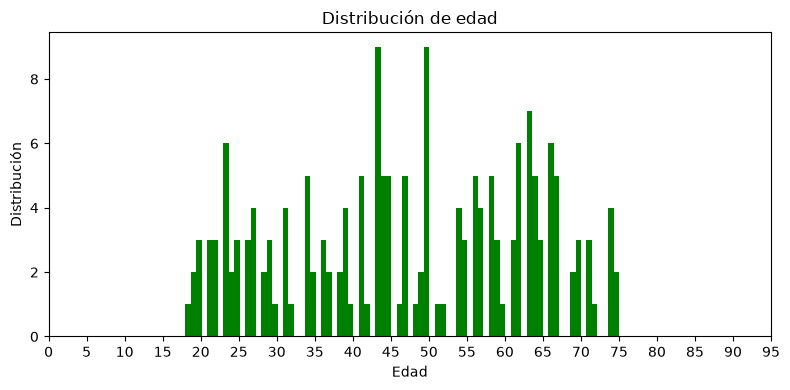

In [16]:
# TODO: crea el histograma de edad

plt.figure(figsize=(8, 4)) #8x4 pulgadas
plt.hist(df["edad"], bins = 80, color = "green")
plt.xlabel("Edad")
plt.xticks(range(0,100, 5))
plt.ylabel("Distribución")
plt.title("Distribución de edad")
plt.tight_layout()
plt.show()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Que hay varios picos de edad, no hay menores de edad, y que los clientes se concentran desde los 20 hasta los 75 años.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

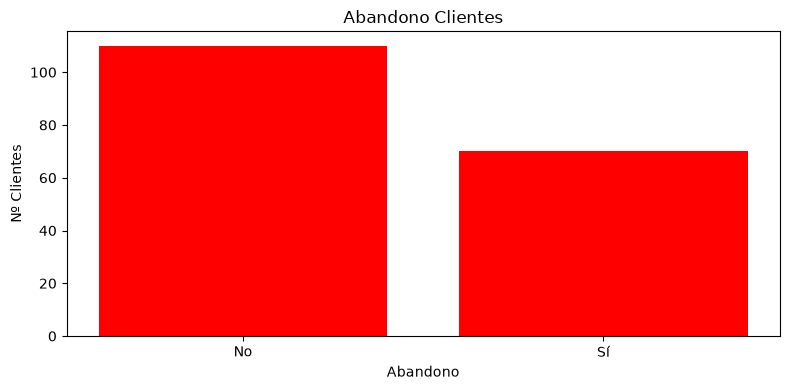

In [17]:
# TODO: crea el gráfico de barras
n_abandonos = df["abandono"].value_counts()
plt.figure(figsize= (8, 4))
plt.bar(n_abandonos.index, n_abandonos.values, color = "red") #Index me da las etiquetas (Si y No), Values me da los valores de las etiquetas.
plt.xlabel("Abandono")
plt.ylabel("Nº Clientes")
plt.title("Abandono Clientes")
plt.tight_layout()
plt.show()


### Interpretación

Describe brevemente qué muestra el gráfico.

Muestra el número de clientes que han abandonado y los que no.

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

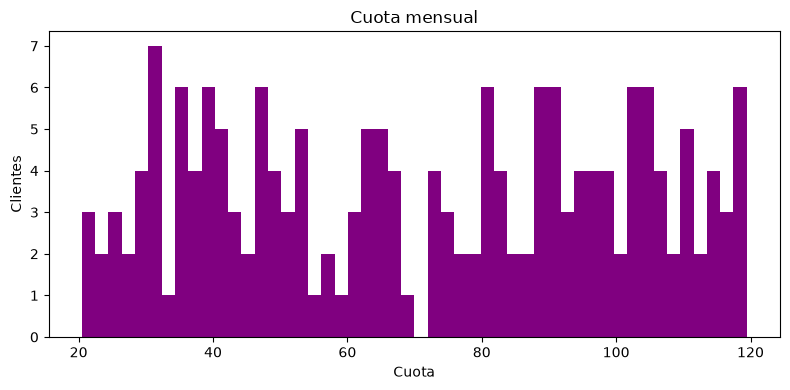

In [36]:
# TODO: crea el histograma de cuota_mensual
plt.figure(figsize= (8,4))
plt.hist(df["cuota_mensual"], bins = 50, color = "purple")
plt.xlabel("Cuota")
plt.ylabel("Clientes")
plt.title("Cuota mensual")
plt.tight_layout()
plt.show()

### Interpretación

Analiza visualmente la distribución.

La gente suele tener cuotas mensuales parecidas. Y la cuota en 70 no suele tener clientes.

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

$$
x = edad
$$
$$
y = cuota\_mensual
$$

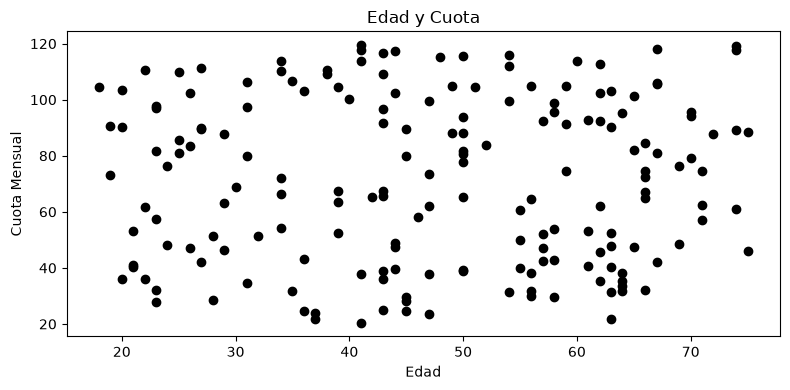

In [44]:
plt.figure(figsize= (8,4))
x = df["edad"]
y = df["cuota_mensual"]
plt.scatter(x, y, color = "black")
plt.xlabel("Edad")
plt.ylabel("Cuota Mensual")
plt.title("Edad y Cuota")
plt.tight_layout()
plt.show()


### Interpretación

- ¿Qué representa cada punto?
- ¿Observas a simple vista alguna relación clara entre ambas variables?

No es necesario realizar un análisis estadístico.

Escribe aquí tu respuesta.

## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [20]:
# TODO: crea y


# TODO: muestra sus cinco primeros valores

### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

Escribe aquí tu respuesta.

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [21]:
# TODO: crea X


# TODO: muestra las dimensiones de X

### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

\[
X.shape = (n,\ ?)
\]

**¿Qué número debe aparecer en `?`? ¿Por qué?**

Escribe aquí tu respuesta.

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?
2. ¿Por qué?
3. ¿Es clasificación o regresión?
4. ¿Por qué?
5. ¿Es clasificación binaria o multiclase?
6. ¿Cuáles son las clases?

### Respuesta

Escribe aquí tu razonamiento.

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?
2. ¿Seguiríamos teniendo exactamente el mismo \(X\)?
3. ¿Sería clasificación o regresión?
4. ¿Seguiría siendo aprendizaje supervisado?
5. Justifica cada respuesta.

### Respuesta

Escribe aquí tu razonamiento.

## Parte 12 - Análisis crítico

### Ejercicio 24 - ¿Utilizarías `cliente_id`?

Los identificadores tienen valores como:

`10001, 10002, 10003, 10004, ...`

¿Utilizarías esta columna como característica para predecir el abandono?

No respondas únicamente «sí» o «no». Razona tu decisión.

### Respuesta

Escribe aquí tu respuesta.

### Ejercicio 25 - ¿Estamos preparados para entrenar?

Después del análisis anterior, alguien propone ejecutar directamente:

```python
modelo.fit(X, y)
```

¿Estamos preparados?

Identifica **al menos cuatro cuestiones** que deberíamos estudiar o resolver antes de entrenar el modelo.

No necesitas explicar todavía cómo resolverlas.

### Respuesta

1. 
2. 
3. 
4.

## Parte 13 - Conclusiones

### Ejercicio 26 - Informe final

Escribe entre **8 y 12 líneas** resumiendo lo que has descubierto.

Debes incluir como mínimo:

- tamaño del dataset
- principales tipos de variables
- comportamiento de `abandono`
- alguna observación de las estadísticas
- alguna observación de las visualizaciones
- cuáles son \(X\) e \(y\)
- tipo de problema de Machine Learning
- qué pasos deberían realizarse antes de entrenar

### Conclusiones

Escribe aquí tu informe.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [22]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna


# 2. Clientes agrupados por tipo_contrato y abandono


# 3. Cuota mensual media según abandono


# 4. Satisfacción media según abandono

# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`